# Test loss plots

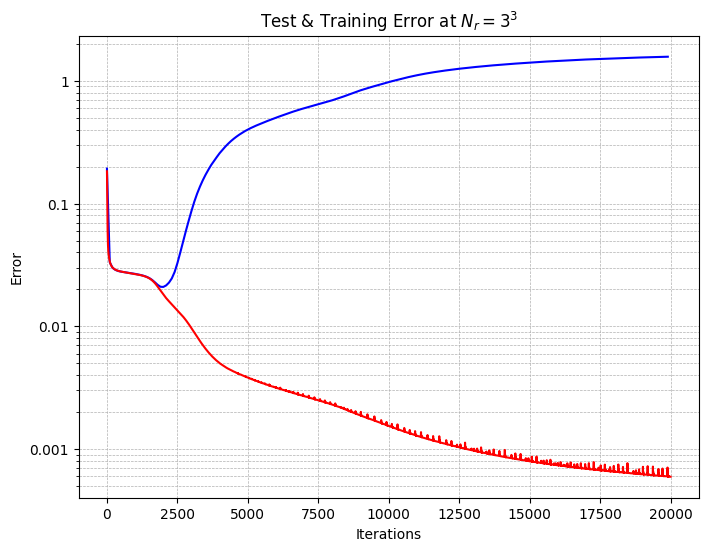

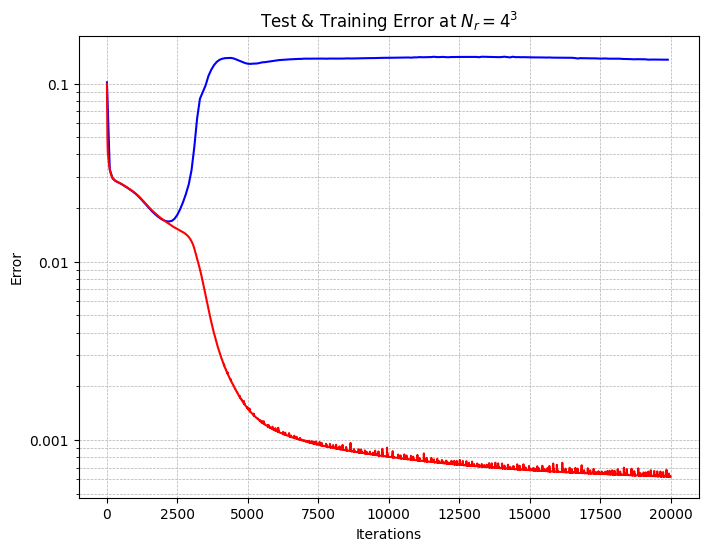

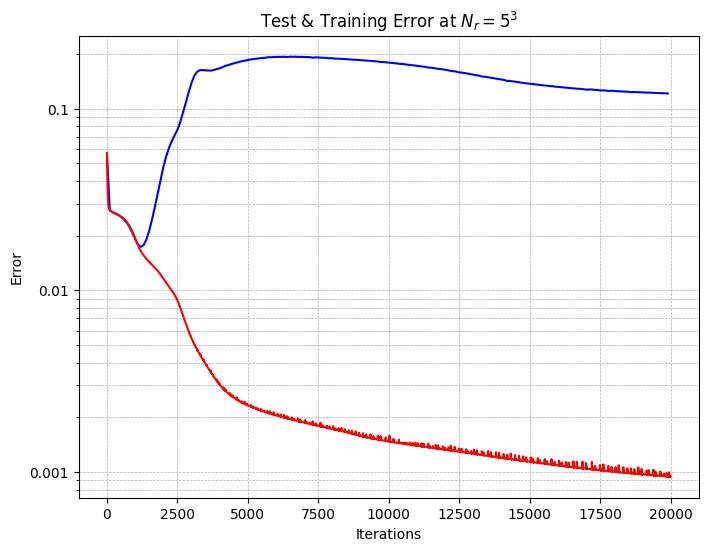

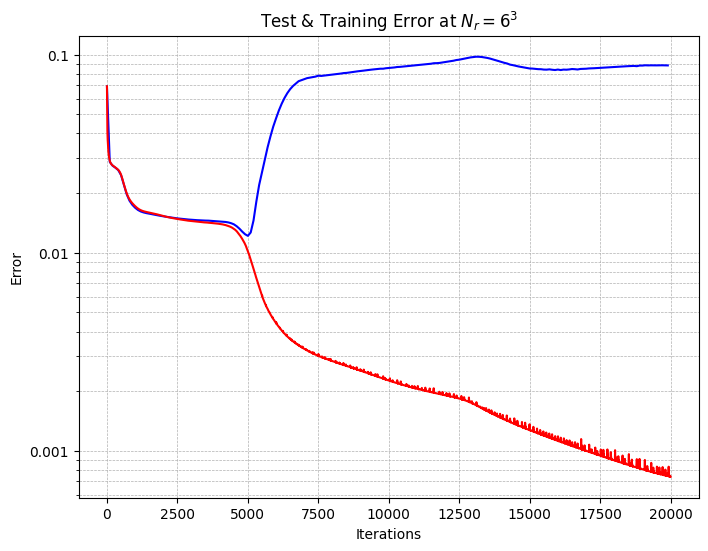

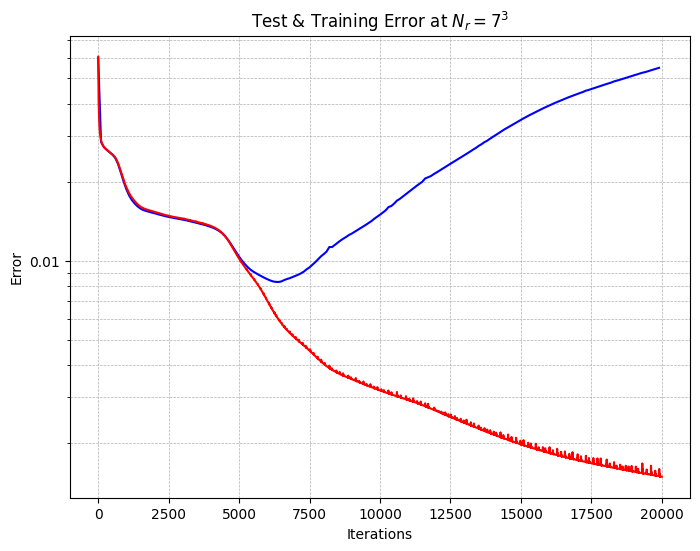

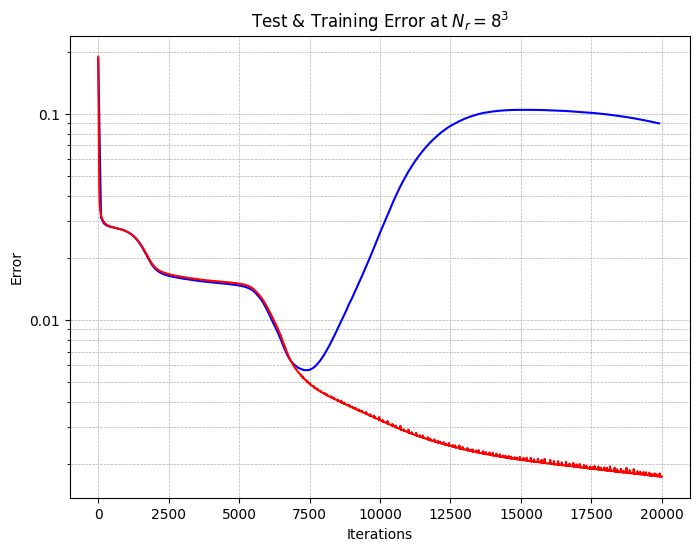

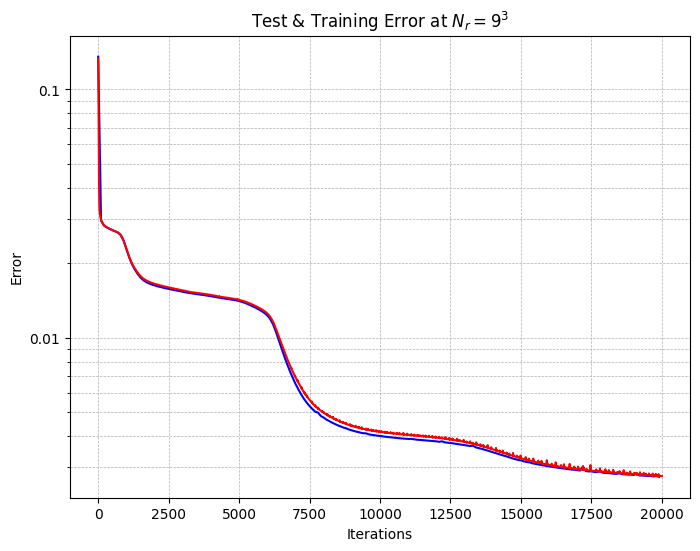

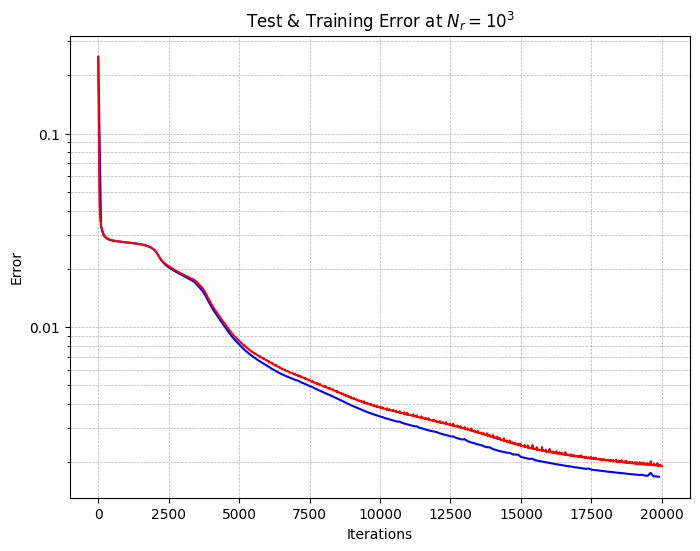

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker

N_rs = [3, 4, 5, 6, 7, 8, 9, 10]
results = np.load(f"../result_NS2_tanh3_dNs_[30]_Nrs_{N_rs}_i_20000.npz")
test_errors = results['test']
train_errors = results['train']


for i in range(len(N_rs)):
  plt.figure(figsize=(8,6))
  plt.plot(np.arange(200)*100, test_errors[i,0,:],color='blue', label="Test Error")
  plt.plot(np.arange(20000), train_errors[i,0,:],color='red', label='Training Error')
  plt.yscale('log')

  plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))
  # plt.gca().yaxis.set_minor_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))

  plt.xlabel("Iterations")
  plt.ylabel("Error")
  # plt.title("True Error at multiple Ns")
  plt.title(f"Test & Training Error at $N_r={N_rs[i]}^3$")

  # plt.legend()
  plt.grid(True, which="both", linestyle="--", linewidth=0.5)
  plt.show()

# Plots

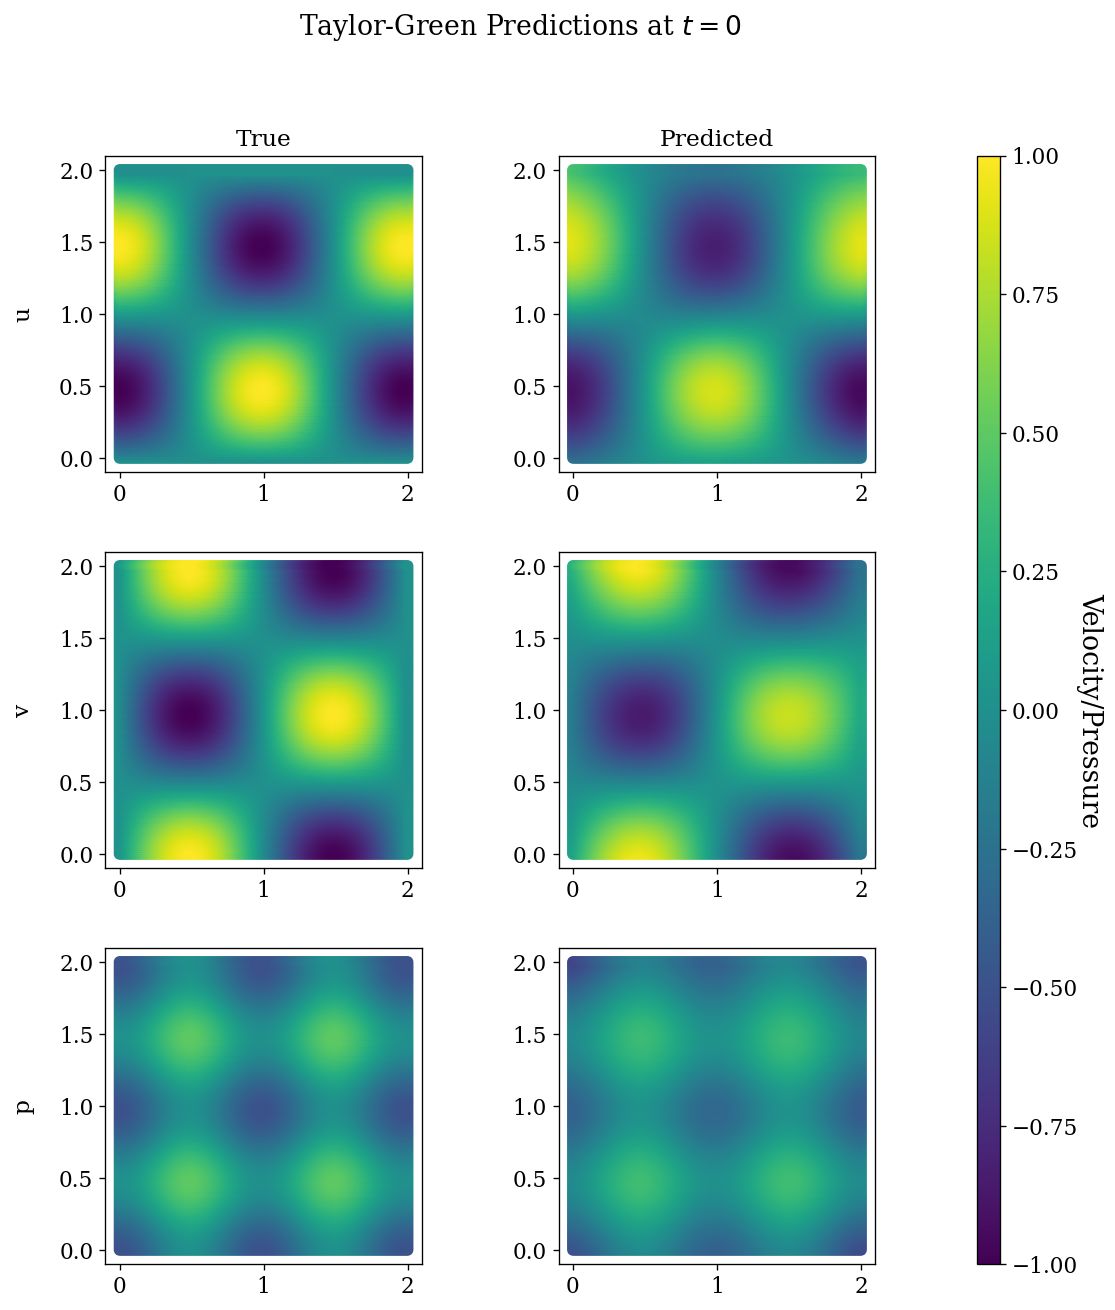

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

min_xyt, max_xyt = 0, 2
max_t=1
nu = 0.01
rho = 1
t_input = 0
net_name = "../weights_NS2_tanh3_dNs_[30]_Nrs_[3, 4, 5, 6, 7, 8, 9, 10]_i_20000.pt"
tanh3act = True # Set to True to use tanh^3 activation, False for tanh.

class TanhCubed(torch.nn.Module):
    def forward(self, x):
        return torch.tanh(x) ** 3

class TwoLayerNN(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(TwoLayerNN, self).__init__()
        self.layer1 = torch.nn.Linear(input_size, hidden_size)  # First layer (trainable)
        self.layer2 = torch.nn.Linear(hidden_size, output_size)  # Second layer (frozen)
        self.activation = TanhCubed()

    def forward(self, x):
        if tanh3act:
           x = self.activation(self.layer1(x))
        else:
            x = torch.tanh(self.layer1(x))
        x = self.layer2(x)  # This layer will not be trained
        return x
N_r = 10

# Replace the middle layer width with the width of the net being plotted
NN = TwoLayerNN(3, 30, 3)

NN.load_state_dict(torch.load(net_name,weights_only=True,map_location=torch.device('cpu'))[f'net_Nr_{N_r}'])
NN.eval()

def u_sol(x,y, t):
    u = -1 * torch.cos(torch.pi * x) * torch.sin(torch.pi * y) * torch.exp(-2 * (torch.pi**2) * nu * t)
    v = torch.sin(torch.pi * x) * torch.cos(torch.pi * y) * torch.exp(-2 * (torch.pi**2) * nu * t)
    p = rho / -4 * (torch.cos(2*torch.pi*x)+torch.cos(2*torch.pi*y)) * torch.exp(-4 * (torch.pi**2) * nu * t)
    return torch.stack((u, v, p),dim=-1)

x, y = torch.meshgrid(
        torch.linspace(0, max_xyt, 128),
        torch.linspace(0, max_xyt, 128),
        indexing = "xy"
    )
t = torch.ones_like(x) * t_input

data = np.zeros([3, 2, 128, 128])
data[:, 0, :, :] = u_sol(x, y, t).detach().numpy().transpose((2, 0, 1))
# data[:, 1, :, :] = NN(torch.stack((x, y, t), dim=-1)).detach().numpy().transpose((2, 0, 1))
data[:, 1, :, :] = NN(torch.stack((x, y, t), dim=-1)).detach().numpy().transpose((2, 0, 1))

rows, cols = 3, 2
row_labels = ["u", "v", "p"]
col_labels = ["True", "Predicted"]

vmin, vmax = -1, 1

fig = plt.figure(figsize=(10, 12))
fig.suptitle(f"Taylor-Green Predictions at $t=0$", fontsize=16)

# Create gridspec with a narrow column on the right for the colorbar
gs = gridspec.GridSpec(rows, cols + 1, width_ratios=[1, 1, 0.06], wspace=0.25, hspace=0.25)

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'legend.fontsize': 14,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'figure.dpi': 120
})

axes = []
scatter_handles = []

# Create scatter subplots (only first 2 columns)
for r in range(rows):
    row_axes = []
    for c in range(cols):
        ax = fig.add_subplot(gs[r, c])
        row_axes.append(ax)

        cvals = data[r, c, :]
        sc = ax.scatter(x, y, c=cvals, vmin=vmin, vmax=vmax)

        ax.set_aspect("equal", adjustable="box")  # ensures square plots

        scatter_handles.append(sc)
    axes.append(row_axes)

# Column titles
for c in range(cols):
    axes[0][c].set_title(col_labels[c], fontsize=14)

# Row labels
for r in range(rows):
    axes[r][0].set_ylabel(row_labels[r], fontsize=14, rotation=90, labelpad=15)

# One shared colorbar in the reserved column
cbar = fig.colorbar(
    scatter_handles[0],
    cax=fig.add_subplot(gs[:, -1])  # spanning all rows, last column
)
cbar.set_label("Velocity/Pressure", rotation=270, labelpad=15)

plt.show()
